# L4: Fallbacks with Branching Pipelines

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [16]:
from dotenv import load_dotenv

_ = load_dotenv()

In [3]:
from haystack import Pipeline, Document
from haystack.components.routers import ConditionalRouter
from haystack.components.builders.prompt_builder import PromptBuilder
from haystack.components.generators import OpenAIGenerator
from haystack.components.retrievers.in_memory import InMemoryBM25Retriever
from haystack.components.websearch.serper_dev import SerperDevWebSearch
from haystack.document_stores.in_memory import InMemoryDocumentStore

### Index Documents into InMemoryDocumentStore

In [4]:
documents = [
    Document(content="Retrievers: Retrieves relevant documents to a user query using keyword search or semantic search."),
    Document(content="Embedders: Creates embeddings for text or documents."),
    Document(content="Generators: Use a number of model providers to generate answers or content based on a prompt"),
    Document(content="FileConvertes: Converts different file types like TXT, Markdown, PDF, etc. into Haystack Document type'")
]

document_store = InMemoryDocumentStore()
document_store.write_documents(documents=documents)

4

### Create RAG Pipeline

In [5]:
rag_prompt_template = """
Answer the following query given the documents.
If the answer is not contained within the documents, reply with 'no_answer'
Query: {{query}}
Documents:
{% for document in documents %}
    {{document.content}}
{% endfor %}
"""

In [6]:
rag = Pipeline()
rag.add_component("retriever", InMemoryBM25Retriever(document_store=document_store))
rag.add_component("prompt_builder", PromptBuilder(template=rag_prompt_template))
rag.add_component("llm", OpenAIGenerator())

rag.connect("retriever.documents", "prompt_builder.documents")
rag.connect("prompt_builder", "llm")

PromptBuilder has 2 prompt variables, but `required_variables` is not set. By default, all prompt variables are treated as optional, which may lead to unintended behavior in multi-branch pipelines. To avoid unexpected execution, ensure that variables intended to be required are explicitly set in `required_variables`.


🚅 Components
  - retriever: InMemoryBM25Retriever
  - prompt_builder: PromptBuilder
  - llm: OpenAIGenerator
🛤️ Connections
  - retriever.documents -> prompt_builder.documents (list[Document])
  - prompt_builder.prompt -> llm.prompt (str)

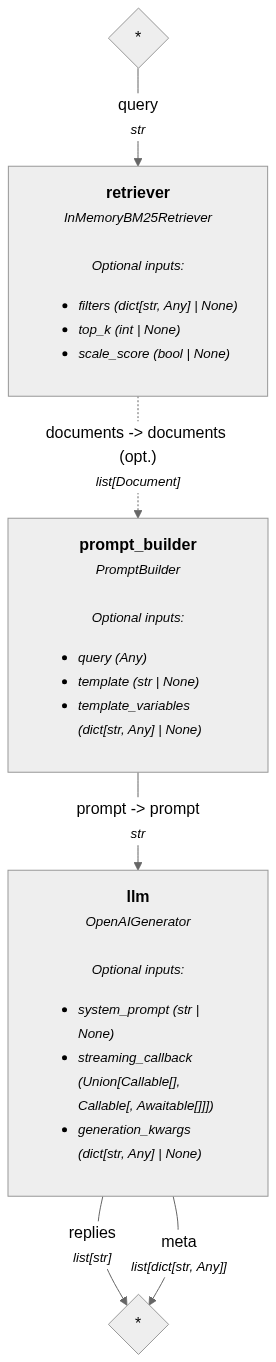

In [7]:
rag.show()

In [8]:
query = "What is a retriever for?"

rag.run({
    "retriever": {
        "query": query
    },
    "prompt_builder": {
        "query": query
    }
})

{'llm': {'replies': ['A retriever retrieves relevant documents for a user query using keyword search or semantic search.'],
  'meta': [{'model': 'gpt-5-mini-2025-08-07',
    'index': 0,
    'finish_reason': 'stop',
    'usage': {'completion_tokens': 154,
     'prompt_tokens': 116,
     'total_tokens': 270,
     'completion_tokens_details': {'accepted_prediction_tokens': 0,
      'audio_tokens': 0,
      'reasoning_tokens': 128,
      'rejected_prediction_tokens': 0},
     'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}}]}}

### Create Conditional Routes

Now that you got the model to respond with an answer or `no_answer`, you can create pipeline branches that are activated according to this response using the [`ConditionalRouter`](https://docs.haystack.deepset.ai/docs/conditionalrouter?utm_campaign=developer-relations&utm_source=dlai) component for this.

In [9]:
routes = [
    {
        "condition": "{{'no_answer' in replies[0]|lower}}",
        "output": "{{query}}",
        "output_name": "go_to_websearch",
        "output_type": str
    },
    {
        "condition": "{{'no_answer' not in replies[0]|lower}}",
        "output": "{{replies[0]}}",
        "output_name": "answer",
        "output_type": str
    }
]

In [10]:
router = ConditionalRouter(routes=routes)
router.run(replies=["Geoff is my friend"], query="Who is Geoff?")

{'answer': 'Geoff is my friend'}

In [11]:
router.run(replies=["No_answer"], query="Who is Geoff?")

{'go_to_websearch': 'Who is Geoff?'}

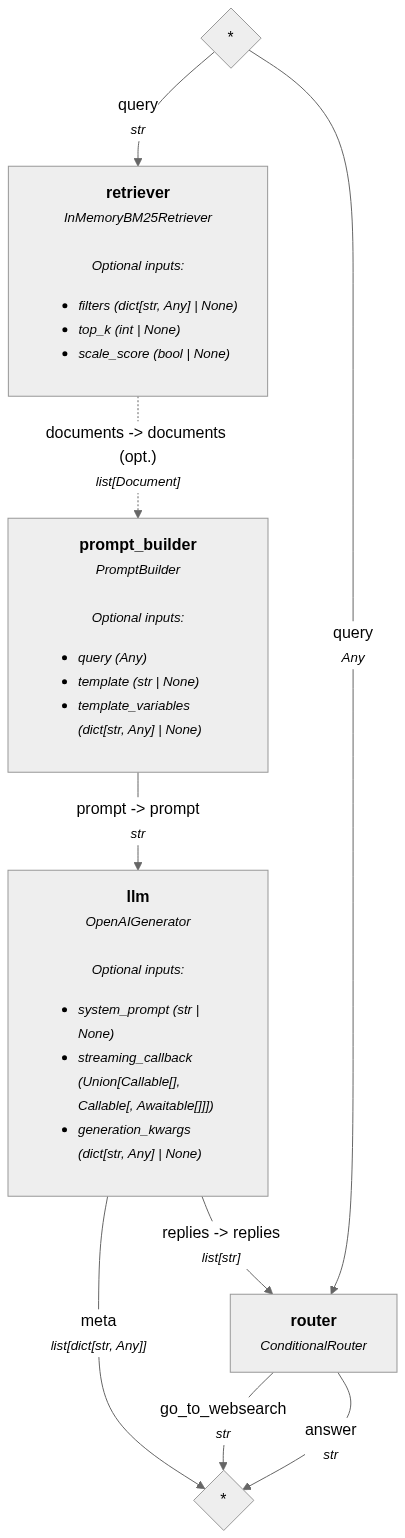

In [12]:
rag.add_component("router", ConditionalRouter(routes=routes))
rag.connect("llm.replies", "router.replies")

rag.show()

In [13]:
query = "What Mistral components does Haystack have?"

rag.run(
    {
        "prompt_builder": {
            "query": query
        },
        "retriever": {
            "query": query
        },
        "router": {
            "query": query
        }
    }
)

{'llm': {'meta': [{'model': 'gpt-5-mini-2025-08-07',
    'index': 0,
    'finish_reason': 'stop',
    'usage': {'completion_tokens': 139,
     'prompt_tokens': 119,
     'total_tokens': 258,
     'completion_tokens_details': {'accepted_prediction_tokens': 0,
      'audio_tokens': 0,
      'reasoning_tokens': 128,
      'rejected_prediction_tokens': 0},
     'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}}]},
 'router': {'go_to_websearch': 'What Mistral components does Haystack have?'}}

### Create Websearch Branch

In [14]:
prompt_for_websearch = """
Answer the following query given the documents retrieved from the web.
Your answer should indicate that your answer was generated from websearch.
You can also reference the URLs that the answer was generated from

Query: {{query}}
Documents:
{% for document in documents %}
    {{document.content}}
{% endfor %}
"""

### Build a Pipeline with Conditional Routes

PromptBuilder has 2 prompt variables, but `required_variables` is not set. By default, all prompt variables are treated as optional, which may lead to unintended behavior in multi-branch pipelines. To avoid unexpected execution, ensure that variables intended to be required are explicitly set in `required_variables`.
PromptBuilder has 2 prompt variables, but `required_variables` is not set. By default, all prompt variables are treated as optional, which may lead to unintended behavior in multi-branch pipelines. To avoid unexpected execution, ensure that variables intended to be required are explicitly set in `required_variables`.


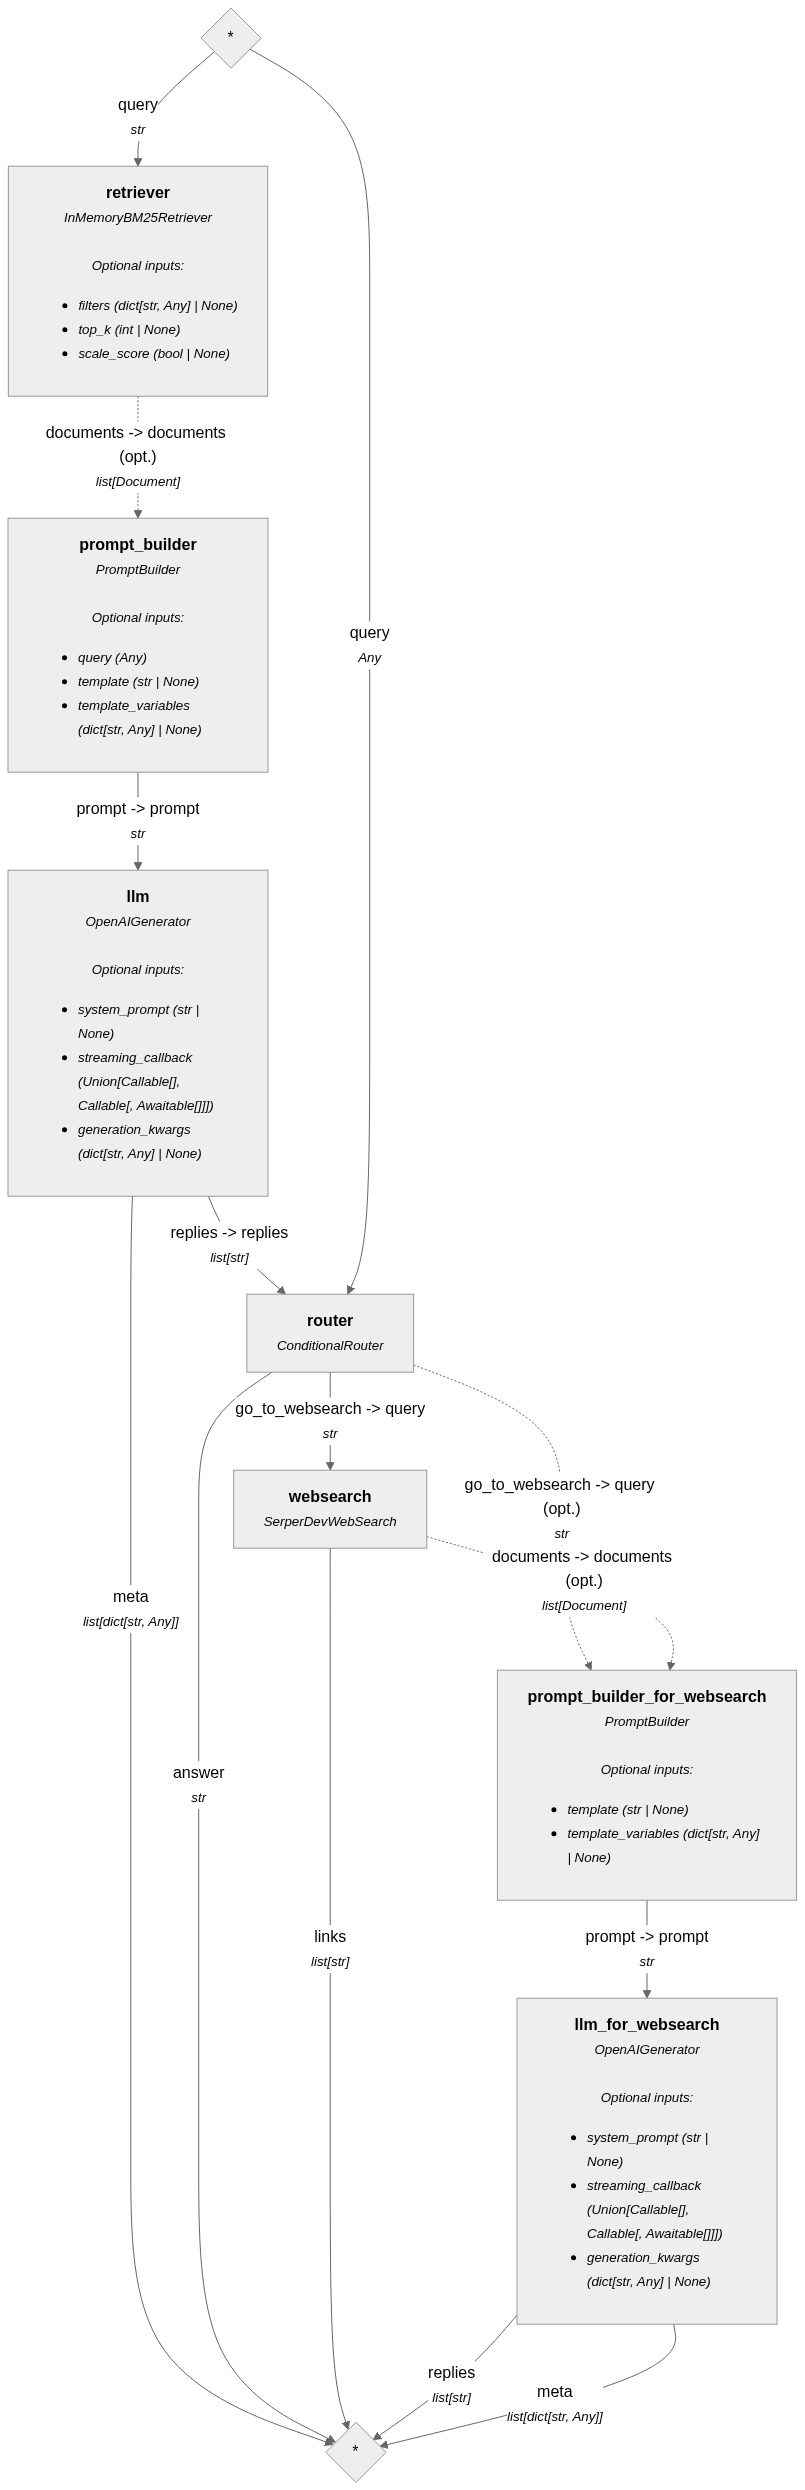

In [17]:
rag_or_websearch = Pipeline()

rag_or_websearch.add_component("retriever", InMemoryBM25Retriever(document_store=document_store))
rag_or_websearch.add_component("prompt_builder", PromptBuilder(template=rag_prompt_template))
rag_or_websearch.add_component("llm", OpenAIGenerator())
rag_or_websearch.add_component("router", ConditionalRouter(routes))
rag_or_websearch.add_component("websearch", SerperDevWebSearch())
rag_or_websearch.add_component("prompt_builder_for_websearch", PromptBuilder(template=prompt_for_websearch))
rag_or_websearch.add_component("llm_for_websearch", OpenAIGenerator())

rag_or_websearch.connect("retriever", "prompt_builder.documents")
rag_or_websearch.connect("prompt_builder", "llm")
rag_or_websearch.connect("llm.replies", "router.replies")
rag_or_websearch.connect("router.go_to_websearch", "websearch.query")
rag_or_websearch.connect("router.go_to_websearch", "prompt_builder_for_websearch.query")
rag_or_websearch.connect("websearch.documents", "prompt_builder_for_websearch.documents")
rag_or_websearch.connect("prompt_builder_for_websearch", "llm_for_websearch")

rag_or_websearch.show()

In [18]:
query = "What is a retriever for?"

rag_or_websearch.run({
    "prompt_builder": {"query": query},
    "retriever": {"query": query},
    "router": {"query": query}
})

{'llm': {'meta': [{'model': 'gpt-5-mini-2025-08-07',
    'index': 0,
    'finish_reason': 'stop',
    'usage': {'completion_tokens': 90,
     'prompt_tokens': 116,
     'total_tokens': 206,
     'completion_tokens_details': {'accepted_prediction_tokens': 0,
      'audio_tokens': 0,
      'reasoning_tokens': 64,
      'rejected_prediction_tokens': 0},
     'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}}]},
 'router': {'answer': 'A retriever retrieves relevant documents for a user query using keyword search or semantic search.'}}

In [19]:
query = "What Mistral components does Haystack have?"

rag_or_websearch.run({
    "prompt_builder": {"query": query},
    "retriever": {"query": query},
    "router": {"query": query}
})

{'llm': {'meta': [{'model': 'gpt-5-mini-2025-08-07',
    'index': 0,
    'finish_reason': 'stop',
    'usage': {'completion_tokens': 343,
     'prompt_tokens': 119,
     'total_tokens': 462,
     'completion_tokens_details': {'accepted_prediction_tokens': 0,
      'audio_tokens': 0,
      'reasoning_tokens': 256,
      'rejected_prediction_tokens': 0},
     'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}}]},
 'router': {'answer': 'Haystack provides the following components:\n\n- FileConverters: Converts various file types (TXT, Markdown, PDF, etc.) into Haystack Document objects.  \n- Retrievers: Retrieve relevant documents for a user query via keyword or semantic search.  \n- Embedders: Create embeddings for text or documents.  \n- Generators: Use model providers to generate answers or content from a prompt.'}}

In [20]:
query = "Who is the president of the Brazil?"

rag_or_websearch.run({
    "prompt_builder": {"query": query},
    "retriever": {"query": query},
    "router": {"query": query}
})

{'llm': {'meta': [{'model': 'gpt-5-mini-2025-08-07',
    'index': 0,
    'finish_reason': 'stop',
    'usage': {'completion_tokens': 75,
     'prompt_tokens': 117,
     'total_tokens': 192,
     'completion_tokens_details': {'accepted_prediction_tokens': 0,
      'audio_tokens': 0,
      'reasoning_tokens': 64,
      'rejected_prediction_tokens': 0},
     'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}}]},
 'websearch': {'links': ['https://en.wikipedia.org/wiki/Luiz_In%C3%A1cio_Lula_da_Silva',
   'https://en.wikipedia.org/wiki/President_of_Brazil',
   'https://www.gov.br/planalto/en/composition/biography-president-of-the-republic',
   'https://www.youtube.com/watch?v=hG8HZJhB4xo',
   'https://www.pbs.org/newshour/world/once-called-the-worlds-most-popular-politician-lulas-approval-in-brazil-plummeting',
   'https://news.un.org/en/story/2025/09/1165920',
   'https://www.youtube.com/watch?v=D4oODEqVpLI',
   'https://www.bbc.com/news/articles/cdeg2j45p2xo',
   'https://ww

In [21]:
query = "How should I initialize a generator with a Mistral model with Haystack?"

rag_or_websearch.run({
    "prompt_builder": {"query": query},
    "retriever": {"query": query},
    "router": {"query": query}
})

{'llm': {'meta': [{'model': 'gpt-5-mini-2025-08-07',
    'index': 0,
    'finish_reason': 'stop',
    'usage': {'completion_tokens': 75,
     'prompt_tokens': 125,
     'total_tokens': 200,
     'completion_tokens_details': {'accepted_prediction_tokens': 0,
      'audio_tokens': 0,
      'reasoning_tokens': 64,
      'rejected_prediction_tokens': 0},
     'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}}]},
 'websearch': {'links': ['https://docs.haystack.deepset.ai/docs/mistralchatgenerator',
   'https://docs.mistral.ai/cookbooks/third_party-haystack-haystack_chat_with_docs',
   'https://haystack.deepset.ai/integrations/mistral',
   'https://github.com/deepset-ai/haystack-integrations/blob/main/integrations/mistral.md',
   'https://www.youtube.com/watch?v=C5mqILmVUEo',
   'https://zilliz.com/tutorials/rag/haystack-and-haystack-in-memory-store-and-mistral-7b-and-stackit-e5-mistral-7b-instruct',
   'https://medium.com/mitb-for-all/a-gentle-introduction-to-the-llm-multive

In [22]:
query = "What is the capital of France?"

rag_or_websearch.run({
    "prompt_builder": {"query": query},
    "retriever": {"query": query},
    "router": {"query": query}
})

{'llm': {'meta': [{'model': 'gpt-5-mini-2025-08-07',
    'index': 0,
    'finish_reason': 'stop',
    'usage': {'completion_tokens': 75,
     'prompt_tokens': 116,
     'total_tokens': 191,
     'completion_tokens_details': {'accepted_prediction_tokens': 0,
      'audio_tokens': 0,
      'reasoning_tokens': 64,
      'rejected_prediction_tokens': 0},
     'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}}]},
 'websearch': {'links': ['https://en.wikipedia.org/wiki/Paris',
   'https://home.adelphi.edu/~ca19535/page%204.html',
   'https://www.coe.int/en/web/interculturalcities/paris',
   'https://www.britannica.com/place/Paris',
   'https://www.cia-france.com/french-kids-teenage-courses/paris-school/visit-paris',
   'https://www.facebook.com/61551442420211/posts/paris-the-capital-and-largest-city-of-france-is-located-in-the-northern-part-of-/122180773544048080/',
   'https://www.bbc.co.uk/bitesize/articles/z6cjfdm',
   'https://en.wikipedia.org/wiki/List_of_capitals_of_Fra